# Spectral Clustering on Stochastic Block Models (SBM)

## Understanding Community Detection Through Synthetic Networks

This notebook explores:

- Stochastic Block Models (SBM)
- Graph Laplacians
- Eigenvalues and Eigenvectors
- Eigengap Heuristic
- Spectral Clustering
- Community Recovery Performance

Goal:
Understand why spectral clustering works and how graph structure affects community detection.

# 1. Stochastic Block Model (SBM)

A Stochastic Block Model (SBM) is a random graph model used to generate networks with community structure.

Idea:

- Nodes are divided into groups (blocks).
- Nodes within the same community connect with higher probability.
- Nodes across different communities connect with lower probability.

Why use SBM?

Because the true communities are already known, making it an excellent benchmark for testing community detection algorithms.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

from scipy.linalg import eigh

In [2]:
sizes = [8, 8]

probs = [
    [0.9, 0.05],
    [0.05, 0.9]
]
G = nx.stochastic_block_model(sizes, probs, seed=42)

## Explanation
## Experiment : High intra connectivity between edges

sizes = [30,30,30]

This creates:

- Community 1 → 30 nodes
- Community 2 → 30 nodes
- Community 3 → 30 nodes

Total nodes = 90

probs matrix controls edge creation probabilities.

Diagonal entries:

0.8

represent probability of connecting nodes within the same community.

Off-diagonal entries:

0.05

represent probability of connecting nodes from different communities.

This creates strong community structure.

# 2. Visualizing the SBM Graph

Before applying any algorithm, it is useful to observe the generated network.

We use a spring layout.

The spring layout treats edges like springs.

Nodes with many connections tend to stay close together, naturally revealing communities.

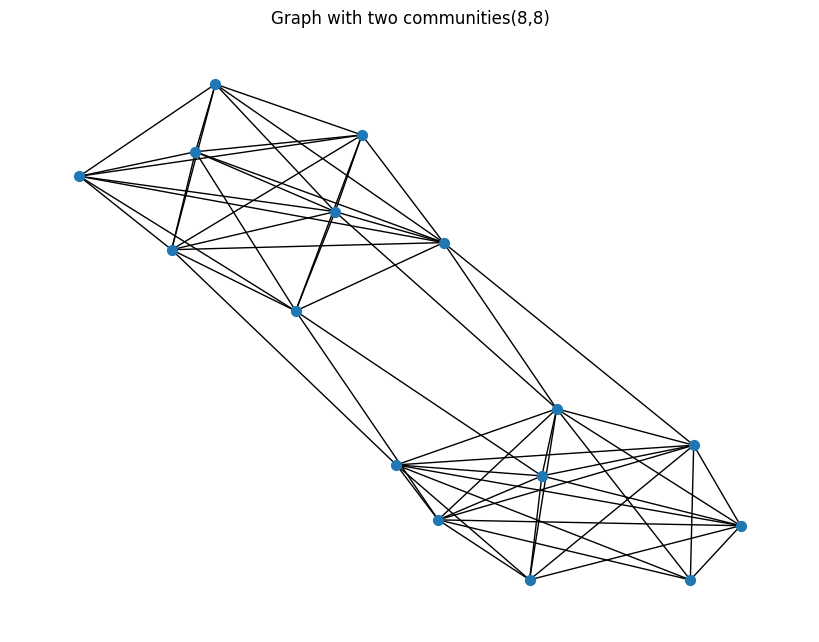

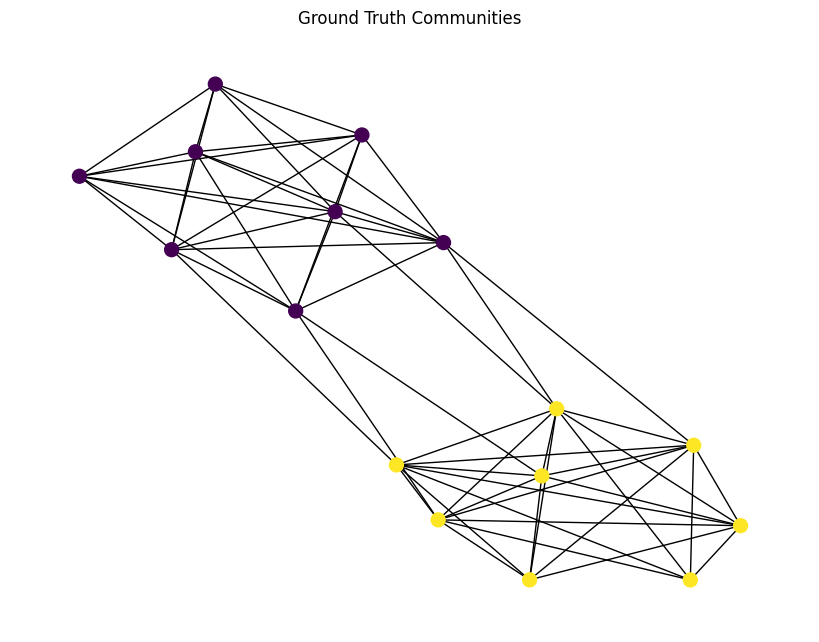

In [3]:
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False
)
plt.title("Graph with two communities(8,8)")
plt.show()
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=true_labels,
    cmap='viridis',
    node_size=100,
    with_labels=False
)

plt.title("Ground Truth Communities")

plt.show()

## Observation

We can visually identify dense regions.

These dense regions correspond to communities.

Notice:

- Many edges exist inside communities.
- Relatively few edges exist between communities.

This is exactly the structure community detection algorithms try to discover automatically.

In [4]:
A = nx.to_numpy_array(G)

print(A.shape)

(16, 16)


# 4. Degree Matrix

The degree of a node is the number of connections it has.

The degree matrix is a diagonal matrix.

Example:

Node Degrees:

3 2 4

Degree Matrix:

[3 0 0]
[0 2 0]
[0 0 4]

Only diagonal entries contain values.
# 5. Graph Laplacian

The Graph Laplacian is one of the most important matrices in network science.

Formula:
        L=D - A
Where:

- D = Degree Matrix
- A = Adjacency Matrix

The Laplacian captures connectivity information.

Community structure naturally appears in its eigenvalues and eigenvectors.

In [5]:
degrees = np.sum(A, axis=1)

D = np.diag(degrees)

print(D.shape)
L = D - A

print(L.shape)

(16, 16)
(16, 16)


# 6. Eigenvalues and Eigenvectors

Why are eigenvalues important?

The spectrum of the Laplacian reveals structural properties of the graph.

Important facts:

1. Smallest eigenvalue is always 0.
2. Number of zero eigenvalues equals number of connected components.
3. Small eigenvalues contain community information.
4. Large eigenvalues often capture local variations.

In [6]:
eigenvalues, eigenvectors = eigh(L)

print("16 Eigenvalues:\n")
print(eigenvalues)

16 Eigenvalues:

[-1.77635684e-15  1.20971619e+00  5.09459488e+00  6.50819586e+00
  7.39245732e+00  8.00000000e+00  8.00000000e+00  8.00000000e+00
  8.00000000e+00  8.00000000e+00  8.49827295e+00  8.72240573e+00
  9.28477138e+00  1.00000000e+01  1.01728621e+01  1.11167236e+01]


First eigen value should be zero according to our discussed properties but in this no value is zero because of floating point precison errors as computers do not store real values directly . If you simplify the first value we will get zero only approximately. 

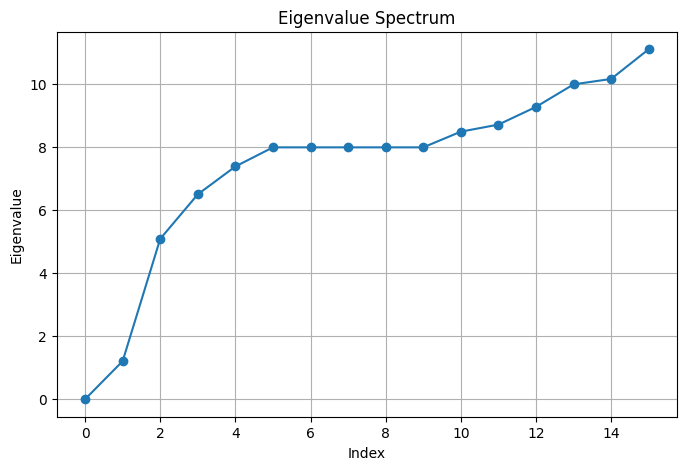

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(eigenvalues)),
    eigenvalues,
    marker='o'
)

plt.xlabel("Index")
plt.ylabel("Eigenvalue")

plt.title("Eigenvalue Spectrum")

plt.grid(True)

plt.show()

In [8]:
gaps = np.diff(eigenvalues)

for i, gap in enumerate(gaps[:10]):
    print(f"Gap {i+1}: {gap:.4f}")

Gap 1: 1.2097
Gap 2: 3.8849
Gap 3: 1.4136
Gap 4: 0.8843
Gap 5: 0.6075
Gap 6: 0.0000
Gap 7: 0.0000
Gap 8: 0.0000
Gap 9: 0.0000
Gap 10: 0.4983


Remember these are gaps not eigen values we no need to sort them we can plot them and based on eigen heuristics we can say how many communities do we have in our graph.

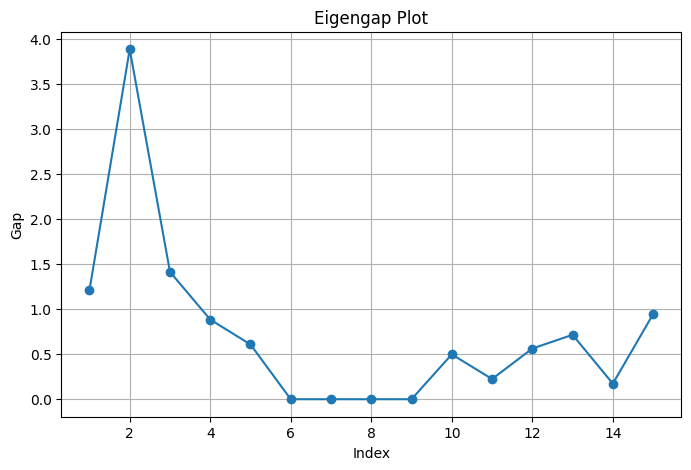

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(gaps)+1),
    gaps,
    marker='o'
)

plt.xlabel("Index")
plt.ylabel("Gap")

plt.title("Eigengap Plot")

plt.grid(True)

plt.show()

# Fiedler Vector

The Fiedler vector is the eigenvector corresponding to the second smallest Laplacian eigenvalue.

For k=2 community detection, nodes can be partitioned based on the sign of their Fiedler vector entries.

Negative values → Community 1

Positive values → Community 2

Fiedler Vector:

[ 0.28900852  0.17703936  0.22325217  0.28900852  0.15354503  0.28900852
  0.22918427  0.31240349 -0.28900852 -0.22918427 -0.22168689 -0.23220012
 -0.28649061 -0.22325217 -0.17703936 -0.30358794]
[1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0]


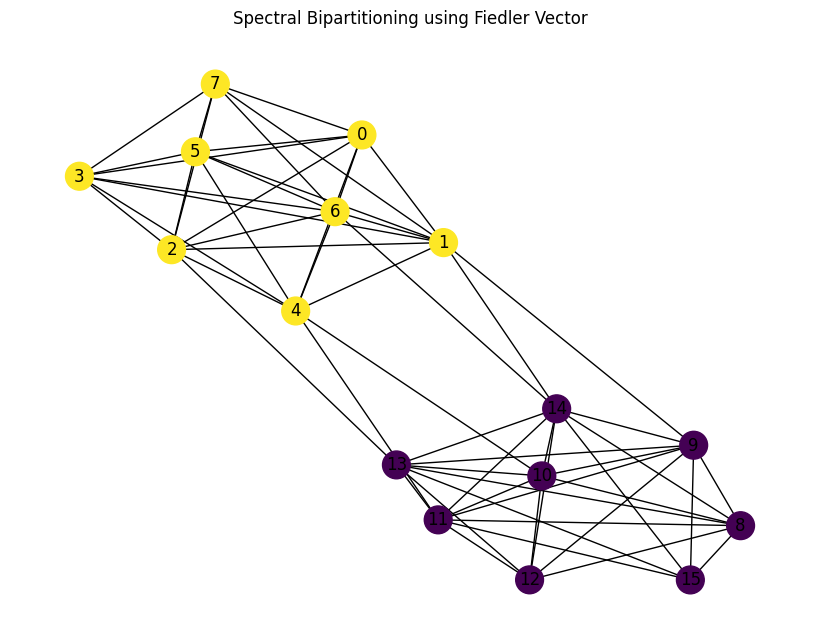

In [10]:
# Fiedler Vector

fiedler_vector = eigenvectors[:, 1]

print("Fiedler Vector:\n")
print(fiedler_vector)
fiedler_labels = (fiedler_vector > 0).astype(int)

print(fiedler_labels)
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=fiedler_labels,
    cmap='viridis',
    node_size=400,
    with_labels=True
)

plt.title("Spectral Bipartitioning using Fiedler Vector")

plt.show()

In [11]:
from sklearn.metrics import adjusted_rand_score
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

ari = adjusted_rand_score(
    true_labels,
    fiedler_labels
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")


Adjusted Rand Index (ARI): 1.0000


# Observation: Determining the Number of Communities using the Eigengap Heuristic

After computing the Laplacian eigenvalues, consecutive differences (eigengaps) were calculated.

Observed gaps:

Gap 1 = 1.2097

Gap 2 = 3.8849  ← Largest Gap

Gap 3 = 1.4136

Gap 4 = 0.8843

Gap 5 = 0.6075

The largest eigengap occurs after the second eigenvalue.

According to the Eigengap Heuristic:

If the largest gap occurs between λₖ and λₖ₊₁, then the graph is estimated to contain k communities.

Since the largest gap occurs after λ₂:

k = 2

Therefore, the graph is expected to contain two major communities.

This observation also agrees with the visual structure of the graph, where two densely connected groups are connected by only a small number of inter-community edges.

Based on this result, two spectral methods are applied:

1. Spectral Bipartitioning using the Fiedler Vector
2. Spectral Clustering using KMeans with k = 2

The results of both approaches are compared in the following sections.

In [12]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=2,
    affinity='precomputed',
    random_state=42
)

spectral_labels = spectral.fit_predict(A)

print(spectral_labels)
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

ari = adjusted_rand_score(
    true_labels,
    spectral_labels
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")


[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
Adjusted Rand Index (ARI): 1.0000


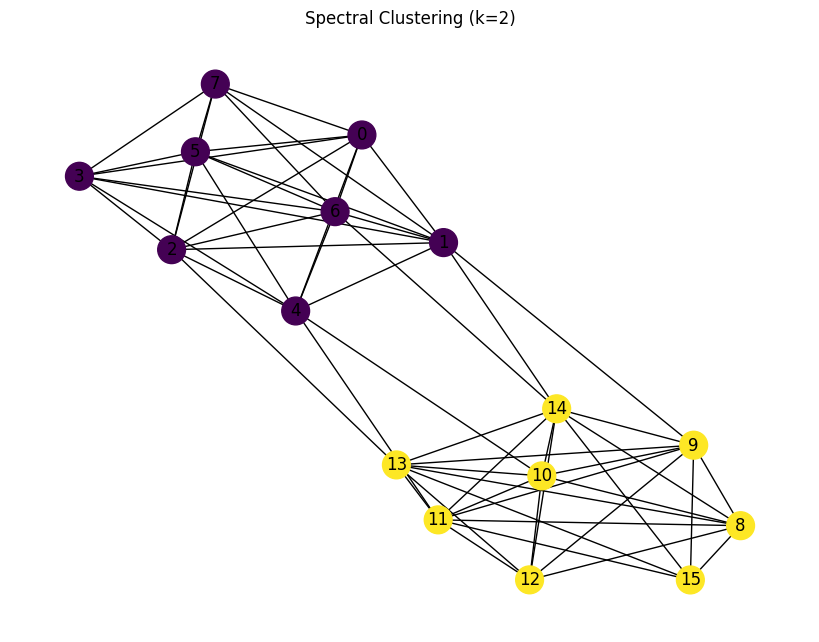

In [13]:
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=spectral_labels,
    cmap='viridis',
    node_size=400,
    with_labels=True
)

plt.title("Spectral Clustering (k=2)")

plt.show()

# Experiment : Weak Community Structure

In this experiment:

- Intra-community probability = 0.5
- Inter-community probability = 0.35

The difference between communities becomes small.

Expected Result:

- Communities become difficult to distinguish.
- Eigengap becomes less obvious.
- Spectral clustering may struggle.

Nodes: 21
Edges: 77


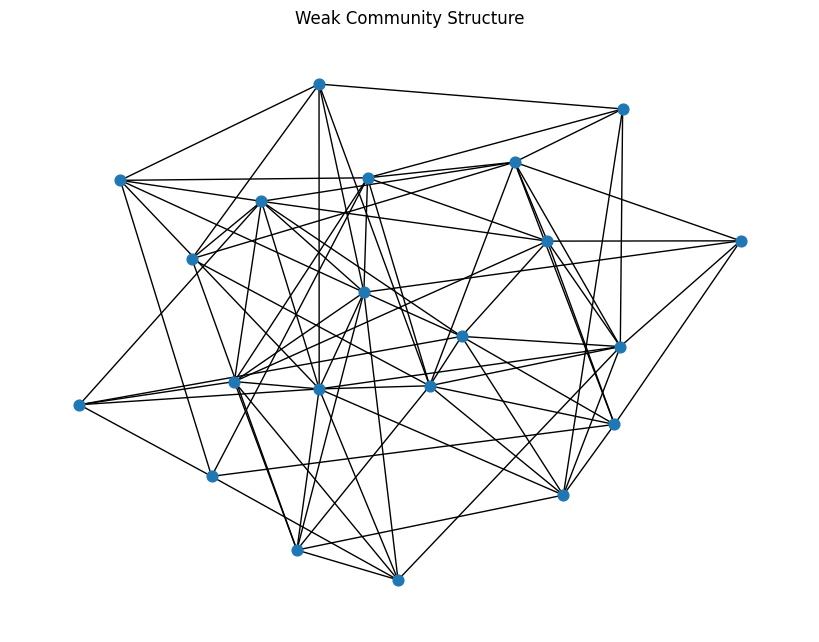

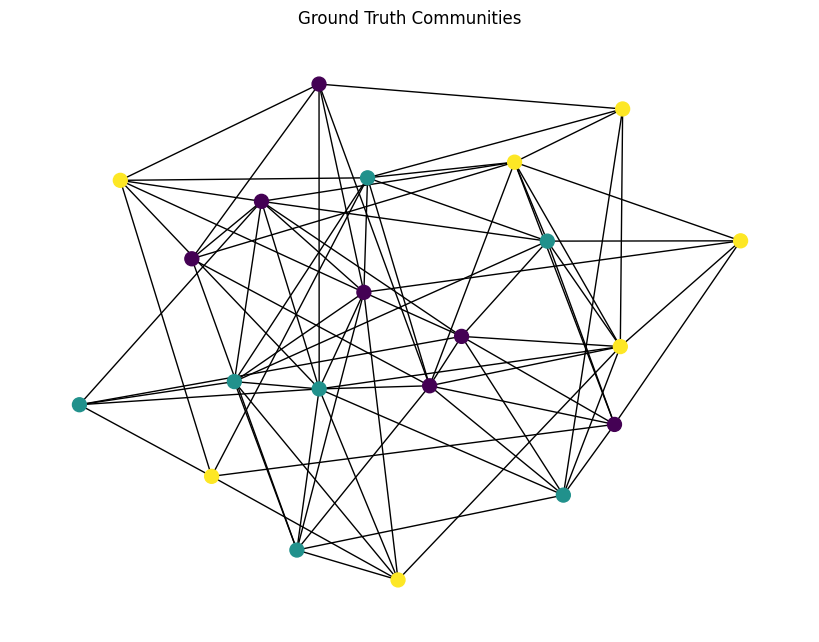

In [14]:
sizes = [7,7,7]

probs = [
    [0.5,0.35,0.35],
    [0.35,0.5,0.35],
    [0.35,0.35,0.5]
]

G = nx.stochastic_block_model(
    sizes,
    probs,
    seed=42
)

print("Nodes:",G.number_of_nodes())
print("Edges:",G.number_of_edges())
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G,seed=42)

nx.draw(
    G,
    pos,
    node_size=60,
    with_labels=False
)

plt.title("Weak Community Structure")
plt.show()
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=true_labels,
    cmap='viridis',
    node_size=100,
    with_labels=False
)

plt.title("Ground Truth Communities")

plt.show()

## Why Compute Eigenvalues?

Spectral clustering relies on the spectrum of the graph Laplacian.

Small eigenvalues contain information about large-scale graph structure.

The number of communities can often be estimated using the eigengap heuristic.
## Eigengap Interpretation

The largest gap between consecutive eigenvalues is identified.

If the largest gap occurs between λ_k and λ_(k+1),

then:

k = estimated number of communities.

This is known as the Eigengap Heuristic.

[1.42108547e-14 3.20972070e+00 3.56674766e+00 4.20346501e+00
 4.57688232e+00 4.71980153e+00 5.14328409e+00 5.71568176e+00
 6.12210040e+00 7.05076393e+00 7.38188921e+00 8.33892897e+00
 8.61567413e+00 8.85790876e+00 9.10496241e+00 9.63950125e+00
 1.01423160e+01 1.11727019e+01 1.14429104e+01 1.21665080e+01
 1.28282516e+01]
Pairwise Eigengap Computation:

Gap 1: λ2 - λ1 = 3.2097 - 0.0000 = 3.2097
Gap 2: λ3 - λ2 = 3.5667 - 3.2097 = 0.3570
Gap 3: λ4 - λ3 = 4.2035 - 3.5667 = 0.6367
Gap 4: λ5 - λ4 = 4.5769 - 4.2035 = 0.3734
Gap 5: λ6 - λ5 = 4.7198 - 4.5769 = 0.1429
Gap 6: λ7 - λ6 = 5.1433 - 4.7198 = 0.4235
Gap 7: λ8 - λ7 = 5.7157 - 5.1433 = 0.5724
Gap 8: λ9 - λ8 = 6.1221 - 5.7157 = 0.4064
Gap 9: λ10 - λ9 = 7.0508 - 6.1221 = 0.9287
Gap 10: λ11 - λ10 = 7.3819 - 7.0508 = 0.3311
Gap 11: λ12 - λ11 = 8.3389 - 7.3819 = 0.9570
Gap 12: λ13 - λ12 = 8.6157 - 8.3389 = 0.2767
Gap 13: λ14 - λ13 = 8.8579 - 8.6157 = 0.2422
Gap 14: λ15 - λ14 = 9.1050 - 8.8579 = 0.2471
Gap 15: λ16 - λ15 = 9.6395 - 9.1050 = 0.53

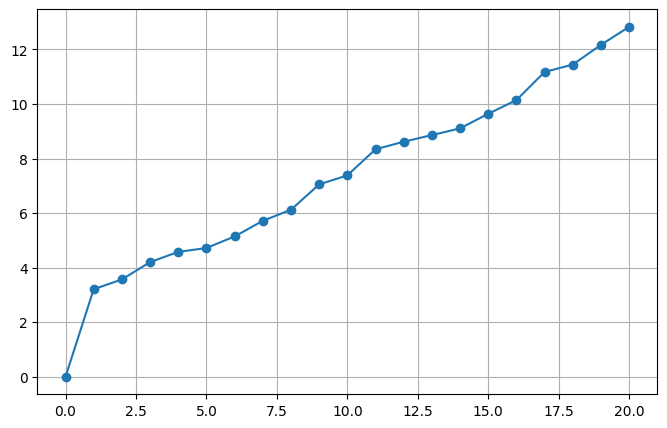

In [15]:
A = nx.to_numpy_array(G)

D = np.diag(np.sum(A,axis=1))

L = D - A

eigenvalues,eigenvectors = eigh(L)

print(eigenvalues)
gaps = np.diff(eigenvalues)

print("Pairwise Eigengap Computation:\n")

for i in range(len(gaps)):
    print(
        f"Gap {i+1}: λ{i+2} - λ{i+1} = "
        f"{eigenvalues[i+1]:.4f} - {eigenvalues[i]:.4f} = {gaps[i]:.4f}"
    )

print("\nIgnoring Gap 1 because λ1 ≈ 0 is a structural property of the Laplacian.")

effective_gaps = gaps[1:]

k = np.argmax(effective_gaps) + 2

print(f"\nEstimated Communities = {k}")
plt.figure(figsize=(8,5))
plt.plot(range(len(eigenvalues)), eigenvalues, marker='o')
plt.grid(True)
plt.show()


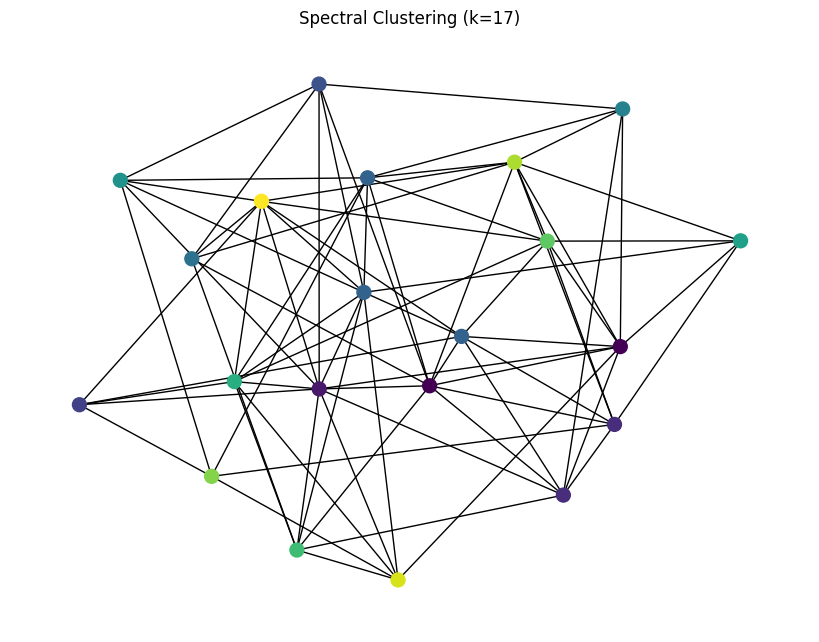

Adjusted Rand Index (ARI): -0.0154


c:\Users\saisi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(labels_pred)


In [16]:
spectral = SpectralClustering(
    n_clusters=k,
    affinity='precomputed',
    random_state=42
)

labels = spectral.fit_predict(A)
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=labels,
    cmap='viridis',
    node_size=100,
    with_labels=False
)

plt.title(f"Spectral Clustering (k={k})")
plt.show()
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

ari = adjusted_rand_score(
    true_labels,
    labels
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")

## Observation

For weak community structure, the eigengap heuristic becomes unreliable.

Although the SBM was generated with three planted communities, the difference between intra-community and inter-community connection probabilities was small.

As a result:

- Communities overlap heavily.
- The Laplacian spectrum does not exhibit a clear eigengap.
- The largest numerical gap appears later in the spectrum.
- The heuristic incorrectly estimates a large number of communities.

This demonstrates an important limitation of eigengap-based community estimation.

When community structure is weak, spectral methods may struggle to recover the true planted communities.

Fiedler Vector:

[-0.081806   -0.02530918 -0.16725401  0.07133041 -0.12068762  0.08773514
 -0.13945202 -0.17704728 -0.11993803  0.09703107  0.03460769  0.44824335
  0.18604276  0.03042964  0.45698101  0.2417575  -0.2192806  -0.34582661
 -0.3232804  -0.17142198  0.23714517]
[0 0 0 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 0 0 1]


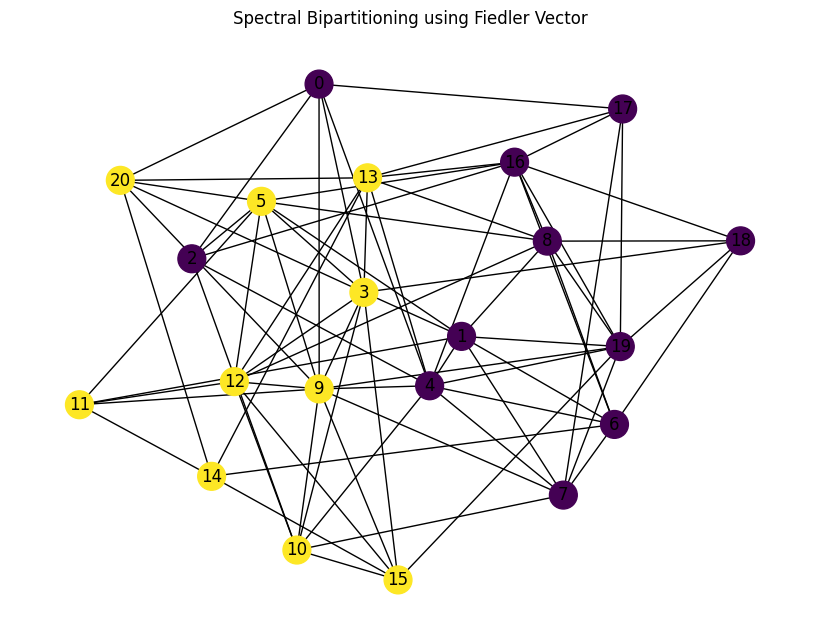

Adjusted Rand Index (ARI): -0.0154


c:\Users\saisi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(labels_pred)


In [17]:
fiedler_vector = eigenvectors[:, 1]

print("Fiedler Vector:\n")
print(fiedler_vector)
fiedler_labels = (fiedler_vector > 0).astype(int)

print(fiedler_labels)
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=fiedler_labels,
    cmap='viridis',
    node_size=400,
    with_labels=True
)

plt.title("Spectral Bipartitioning using Fiedler Vector")

plt.show()
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

ari = adjusted_rand_score(
    true_labels,
    labels
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")

## Observation

Although the SBM was generated with three planted communities, the difference between intra-community and inter-community connection probabilities was relatively small.

Intra-community probability = 0.50

Inter-community probability = 0.35

As a result, the communities overlap significantly.

The Laplacian spectrum provides a weaker community signal, making community recovery more difficult.

The Fiedler vector naturally produces only a two-way partition and therefore merges some of the planted communities.

This demonstrates that spectral methods depend strongly on the strength of the underlying community structure.

# Experiment : Moderate Community Structure

In this experiment:

- Intra-community probability = 0.7
- Inter-community probability = 0.1

The difference between communities becomes moderate.

Expected Result:

- Communities become some what better to distinguish.
- Eigengap becomes better obvious.
- Spectral clustering might give proper communities.

## Ground Truth Community Structure

Since the graph was generated using a Stochastic Block Model (SBM), the true community assignments are known beforehand.

The parameter:

```python
sizes = [7,7,7]
```

creates three planted communities.

These labels represent the actual communities used during graph generation and serve as a reference when evaluating the performance of spectral clustering.

By comparing the detected communities with the ground truth communities, we can measure how accurately the algorithm recovers the underlying structure.

Nodes: 21
Edges: 69


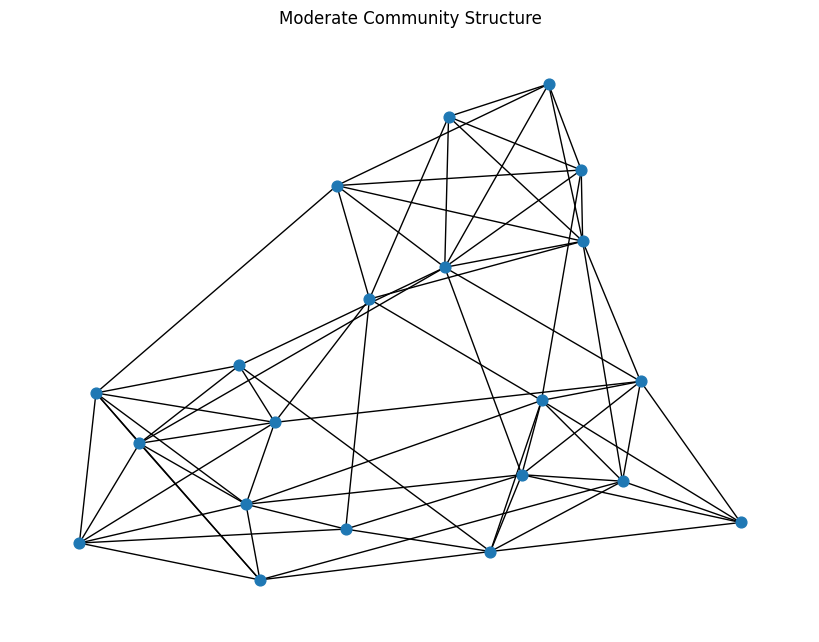

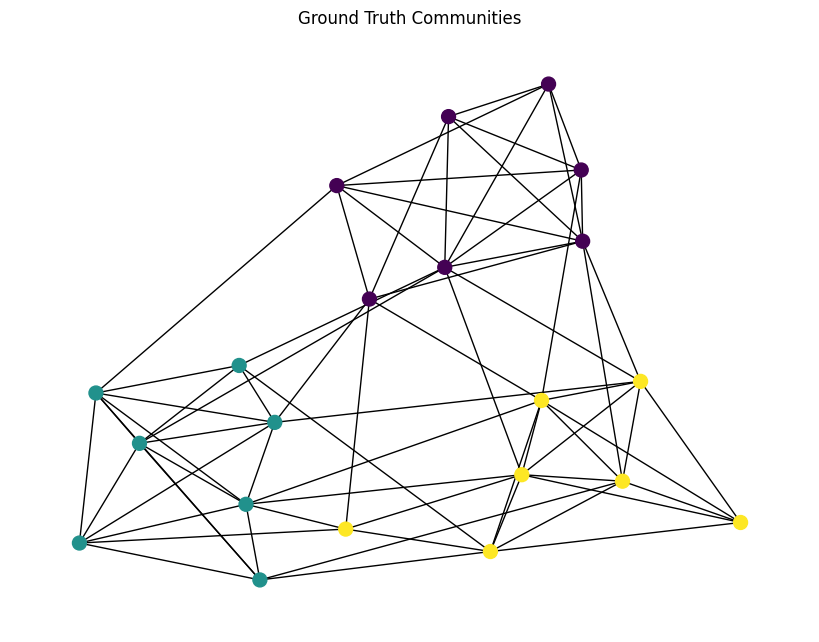

In [18]:
sizes = [7,7,7]

probs = [
    [0.7,0.1,0.1],
    [0.1,0.7,0.1],
    [0.1,0.1,0.7]
]

G = nx.stochastic_block_model(
    sizes,
    probs,
    seed=42
)

print("Nodes:",G.number_of_nodes())
print("Edges:",G.number_of_edges())
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G,seed=42)

nx.draw(
    G,
    pos,
    node_size=60,
    with_labels=False
)

plt.title("Moderate Community Structure")
plt.show()
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=true_labels,
    cmap='viridis',
    node_size=100,
    with_labels=False
)

plt.title("Ground Truth Communities")

plt.show()

# Estimating the Number of Communities using the Eigengap Heuristic

After computing the Laplacian eigenvalues, the differences between consecutive eigenvalues (eigengaps) are calculated.

```python
gaps = np.diff(eigenvalues)
```

For this graph, the first few gaps were:

Gap 1 = 1.6318

Gap 2 = 0.8242

Gap 3 = 1.4651

Gap 4 = 0.7892

...

## Why is Gap 1 Ignored?

For a connected graph, the Laplacian matrix always has a smallest eigenvalue equal to:

λ₁ = 0

This is a fundamental property of graph Laplacians.

Therefore:

Gap 1 = λ₂ - λ₁

measures the distance from the mandatory zero eigenvalue to the second eigenvalue.

Since λ₁ = 0 always exists regardless of community structure, Gap 1 can be artificially large and may not accurately reflect the true number of communities.

For this reason, only the remaining gaps are considered:

```python
gaps[1:]
```

which produces:

Gap 2 = 0.8242

Gap 3 = 1.4651

Gap 4 = 0.7892

...

The largest remaining gap is:

Gap 3 = 1.4651

## Why is +2 Added?

The function:

```python
np.argmax(gaps[1:])
```

returns the index within the shortened array.

Example:

```python
gaps[1:] =
[
    0.8242,   # Gap 2
    1.4651,   # Gap 3
    0.7892    # Gap 4
]
```

The largest value is:

```text
1.4651
```

which is located at:

```python
index = 1
```

inside the shortened array.

However, this corresponds to:

```text
Gap 3
```

in the original numbering.

Therefore:

```python
k = np.argmax(gaps[1:]) + 2
```

The extra:

+1 → converts array index to gap number

+1 → compensates for removing Gap 1

Thus:

```python
k = 1 + 2 = 3
```

## Final Result

The eigengap heuristic estimates:

```text
Number of Communities = 3
```

This matches the planted community structure used in the Stochastic Block Model:

```python
sizes = [7, 7, 7]
```

which was generated with three underlying communities.

[3.55271368e-15 1.63177990e+00 2.45596488e+00 3.92106562e+00
 4.71028644e+00 5.18674153e+00 5.34763466e+00 5.80306032e+00
 6.28797783e+00 6.41386782e+00 7.02261721e+00 7.34344003e+00
 7.70922510e+00 8.09807206e+00 8.34064950e+00 8.51236693e+00
 8.96217953e+00 9.28668775e+00 9.35431713e+00 1.07589524e+01
 1.08531133e+01]
Pairwise Eigengap Computation:

Gap 1: λ2 - λ1 = 1.6318 - 0.0000 = 1.6318
Gap 2: λ3 - λ2 = 2.4560 - 1.6318 = 0.8242
Gap 3: λ4 - λ3 = 3.9211 - 2.4560 = 1.4651
Gap 4: λ5 - λ4 = 4.7103 - 3.9211 = 0.7892
Gap 5: λ6 - λ5 = 5.1867 - 4.7103 = 0.4765
Gap 6: λ7 - λ6 = 5.3476 - 5.1867 = 0.1609
Gap 7: λ8 - λ7 = 5.8031 - 5.3476 = 0.4554
Gap 8: λ9 - λ8 = 6.2880 - 5.8031 = 0.4849
Gap 9: λ10 - λ9 = 6.4139 - 6.2880 = 0.1259
Gap 10: λ11 - λ10 = 7.0226 - 6.4139 = 0.6087
Gap 11: λ12 - λ11 = 7.3434 - 7.0226 = 0.3208
Gap 12: λ13 - λ12 = 7.7092 - 7.3434 = 0.3658
Gap 13: λ14 - λ13 = 8.0981 - 7.7092 = 0.3888
Gap 14: λ15 - λ14 = 8.3406 - 8.0981 = 0.2426
Gap 15: λ16 - λ15 = 8.5124 - 8.3406 = 0.17

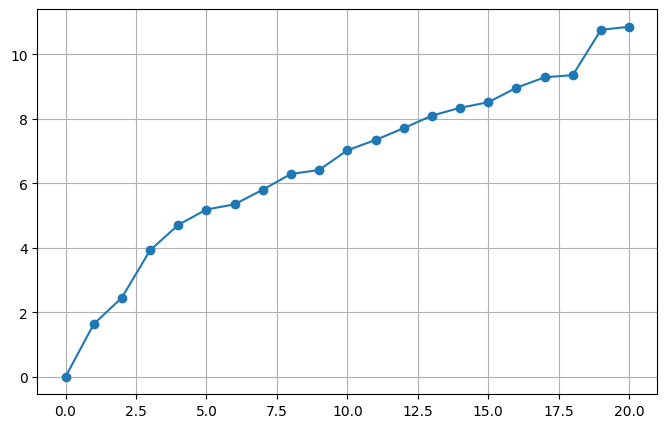

In [19]:
A = nx.to_numpy_array(G)

D = np.diag(np.sum(A,axis=1))

L = D - A

eigenvalues,eigenvectors = eigh(L)

print(eigenvalues)
gaps = np.diff(eigenvalues)

print("Pairwise Eigengap Computation:\n")

for i in range(len(gaps)):
    print(
        f"Gap {i+1}: λ{i+2} - λ{i+1} = "
        f"{eigenvalues[i+1]:.4f} - {eigenvalues[i]:.4f} = {gaps[i]:.4f}"
    )

print("\nIgnoring Gap 1 because λ1 ≈ 0 is a structural property of the Laplacian.")

effective_gaps = gaps[1:]

k = np.argmax(effective_gaps) + 2

print(f"\nEstimated Communities = {k}")
plt.figure(figsize=(8,5))
plt.plot(range(len(eigenvalues)), eigenvalues, marker='o')
plt.grid(True)
plt.show()


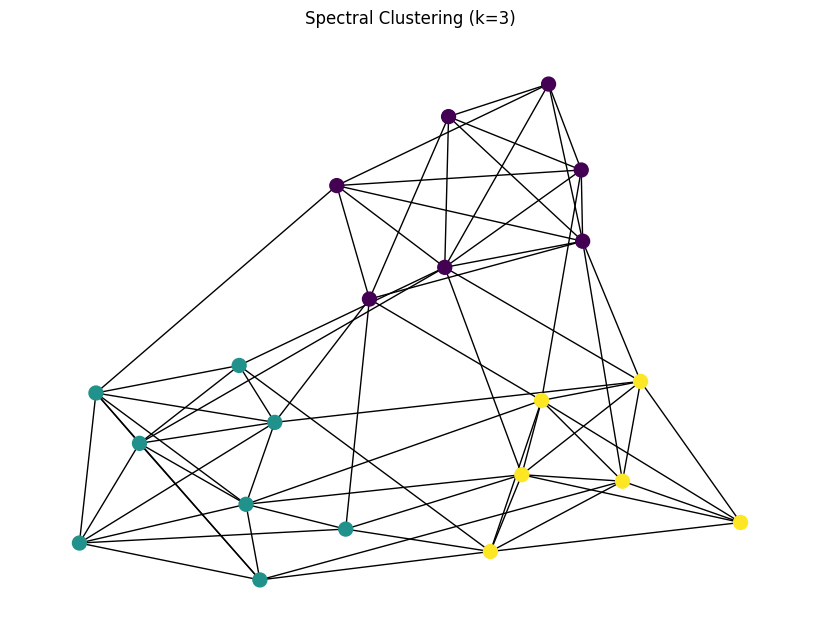

Adjusted Rand Index (ARI): 0.8533


In [20]:
spectral = SpectralClustering(
    n_clusters=k,
    affinity='precomputed',
    random_state=42
)

labels = spectral.fit_predict(A)
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=labels,
    cmap='viridis',
    node_size=100,
    with_labels=False
)

plt.title(f"Spectral Clustering (k={k})")
plt.show()
true_labels = []

for block_id, size in enumerate(sizes):
    true_labels.extend([block_id] * size)

ari = adjusted_rand_score(
    true_labels,
    labels
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# Final Experimental Summary

The following table summarizes the results obtained from SBM graphs with different probability structures.

| Experiment | Intra-Community Probability | Inter-Community Probability | Actual Communities | Eigengap Estimate | ARI Score | Observation |
|------------|----------------------------|-----------------------------|-------------------|------------------|-----------|-------------|
| Strong Structure | 0.90 | 0.02 | 2 | 2 | 1.0000 | Excellent recovery |
| Moderate Structure | 0.70 | 0.10 | 3 | 3 | 0.8533 | Good recovery |
| Weak Structure | 0.50 | 0.35 | 3 | 17 | -0.0154 | Community overlap causes failure |

## Key Observations

1. Spectral clustering performs best when communities are well separated.

2. As inter-community probability increases, communities become less distinguishable.

3. The Laplacian eigenspectrum becomes less informative when community structure weakens.

4. The Eigengap Heuristic works well for strong community structures but may fail when communities overlap significantly.

5. Spectral Bipartitioning naturally produces only two groups, whereas Spectral Clustering can recover multiple communities using KMeans on the spectral embedding.

## Conclusion

The Stochastic Block Model provides a controlled environment for studying community detection algorithms.

Through these experiments, we observed how graph structure directly affects the Laplacian spectrum, eigengap estimation, and spectral clustering performance.

The results demonstrate both the strengths and limitations of spectral methods for community detection.